# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ankita0531/ML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [ ]:
# 1. Question: project definition

research_question = (
    "Can pre-outcome search and engagement signals identify content "
    "likely to experience a significant decline in Google Search impressions, "
    "and can those signals be converted into a ranked refresh-priority queue?"
)

decision_supported = (
    "Which content should a FlyRank editor prioritize for refresh "
    "or further investigation?"
)

unit_of_analysis = "client_hash_id × content_hash_id"

output = (
    "A ranked content-priority queue containing a score, reason code, "
    "and recommended action."
)

wrong_call_cost = {
    "false_positive": "Editorial time may be spent reviewing content that did not need attention.",
    "false_negative": "Content that actually declined may be missed for review."
}

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

print("\nUnit of analysis:")
print(unit_of_analysis)

print("\nOutput:")
print(output)

print("\nCost of wrong calls:")
for error, cost in wrong_call_cost.items():
    print(f"- {error}: {cost}")

Research question:
Can pre-outcome search and engagement signals identify content likely to experience a significant decline in Google Search impressions, and can those signals be converted into a ranked refresh-priority queue?

Decision supported:
Which content should a FlyRank editor prioritize for refresh or further investigation?

Unit of analysis:
client_hash_id × content_hash_id

Output:
A ranked content-priority queue containing a score, reason code, and recommended action.

Cost of wrong calls:
- false_positive: Editorial time may be spent reviewing content that did not need attention.
- false_negative: Content that actually declined may be missed for review.


The analysis is intended for decision support. It does not claim that refreshing a page will cause its search performance to improve, and it does not attempt to predict or prove Google's ranking algorithm.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [ ]:
# Capstone data definition

feature_window = "February 2026"
outcome_window = "March 2026"

unit_of_analysis = "client_hash_id × content_hash_id"

feature_columns = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions",
]

target_definition = (
    "March 2026 GSC impressions decline by more than 20% "
    "relative to February 2026."
)

required_availability = [
    "GSC data available in the feature window",
    "GA4 data available in the feature window",
    "GSC data available in the outcome window",
]

excluded_fields = [
    "client-identifying fields",
    "raw URLs or domains",
    "private search queries",
    "trend_direction",
    "trend_pct",
    "any outcome-derived field",
]

print("Feature window:", feature_window)
print("Outcome window:", outcome_window)
print("Unit of analysis:", unit_of_analysis)

print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

print("\nTarget:")
print(target_definition)

print("\nAvailability requirements:")
for item in required_availability:
    print("-", item)

print("\nExcluded fields:")
for item in excluded_fields:
    print("-", item)

Feature window: February 2026
Outcome window: March 2026
Unit of analysis: client_hash_id × content_hash_id

Features:
- gsc_impressions
- gsc_clicks
- gsc_avg_position
- ga4_sessions
- ga4_engaged_sessions

Target:
March 2026 GSC impressions decline by more than 20% relative to February 2026.

Availability requirements:
- GSC data available in the feature window
- GA4 data available in the feature window
- GSC data available in the outcome window

Excluded fields:
- client-identifying fields
- raw URLs or domains
- private search queries
- trend_direction
- trend_pct
- any outcome-derived field


In [ ]:
# Connect to the FlyRank warehouse

import duckdb
import pandas as pd

con = duckdb.connect()

# Load Hugging Face token from Colab secrets
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

con.execute(f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{HF_TOKEN}'
    )
""")

print("Hugging Face authentication configured.")

Hugging Face authentication configured.


In [ ]:
# Define the February and March warehouse partitions

FEB_REL = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/'
    'fact_content_daily_performance/month=2026-02/*.parquet'
)
"""

MAR_REL = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/'
    'fact_content_daily_performance/month=2026-03/*.parquet'
)
"""

print("February and March data relations defined.")

February and March data relations defined.


In [ ]:
# Verify the February and March data

for name, rel in [("February", FEB_REL), ("March", MAR_REL)]:
    check = con.sql(f"""
        SELECT
            COUNT(*) AS row_count,
            MIN(report_date) AS min_date,
            MAX(report_date) AS max_date
        FROM {rel}
    """).df()

    print(f"\n{name}:")
    display(check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


February:


,row_count,min_date,max_date
0,7355108,2026-02-01,2026-02-28


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


March:


,row_count,min_date,max_date
0,9841378,2026-03-01,2026-03-31


In [ ]:
# Aggregate February data to the analysis grain:
# client_hash_id × content_hash_id

feb = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS feb_impressions,
        SUM(gsc_clicks) AS feb_clicks,
        AVG(gsc_avg_position) AS feb_avg_position,

        SUM(ga4_sessions) AS feb_sessions,
        SUM(ga4_engaged_sessions) AS feb_engaged_sessions

    FROM {FEB_REL}

    WHERE gsc_data_available = TRUE

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print("February content rows:", len(feb))
display(feb.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

February content rows: 153559


,client_hash_id,content_hash_id,feb_impressions,feb_clicks,feb_avg_position,feb_sessions,feb_engaged_sessions
0,client_3ffa76342f366962,content_36bee0a093d0711d,3.0,0.0,5.500000,NaN,NaN
1,client_3ffa76342f366962,content_1546aabff77c05a4,5.0,1.0,5.000000,0.0,0.0
2,client_3ffa76342f366962,content_cae1d5374958a649,96.0,0.0,5.262333,0.0,0.0
3,client_3ffa76342f366962,content_dd66eecf9626cab8,235.0,0.0,6.407819,0.0,0.0
4,client_3ffa76342f366962,content_c51f1e8ef5502177,18.0,0.0,6.961538,0.0,0.0


In [ ]:
# Aggregate March data to the same analysis grain

mar = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS mar_impressions

    FROM {MAR_REL}

    WHERE gsc_data_available = TRUE

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print("March content rows:", len(mar))
display(mar.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March content rows: 176738


,client_hash_id,content_hash_id,mar_impressions
0,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,1140.0
1,client_73cda7b4e4f265ea,content_05597932fe4da067,57.0
2,client_73cda7b4e4f265ea,content_905aa32a0230694e,149.0
3,client_73cda7b4e4f265ea,content_05434271b257bb68,1421.0
4,client_73cda7b4e4f265ea,content_d056587ff7faca0c,2770.0


In [ ]:
# Keep only content that has data in both months

df = feb.merge(
    mar,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Final analytical rows:", len(df))
display(df.head())

Final analytical rows: 134238


,client_hash_id,content_hash_id,feb_impressions,feb_clicks,feb_avg_position,feb_sessions,feb_engaged_sessions,mar_impressions
0,client_3ffa76342f366962,content_1546aabff77c05a4,5.0,1.0,5.000000,0.0,0.0,3.0
1,client_3ffa76342f366962,content_cae1d5374958a649,96.0,0.0,5.262333,0.0,0.0,43.0
2,client_3ffa76342f366962,content_dd66eecf9626cab8,235.0,0.0,6.407819,0.0,0.0,255.0
3,client_3ffa76342f366962,content_c51f1e8ef5502177,18.0,0.0,6.961538,0.0,0.0,15.0
4,client_3ffa76342f366962,content_0674cc4ae0f68a90,74.0,1.0,8.063910,0.0,0.0,11.0


In [ ]:
print("Missing values:")
display(df.isna().sum())

print("\nNumber of unique clients:", df["client_hash_id"].nunique())
print("Number of unique content items:", df["content_hash_id"].nunique())

Missing values:


,0
client_hash_id,0
content_hash_id,0
feb_impressions,0
feb_clicks,0
feb_avg_position,0
feb_sessions,67969
feb_engaged_sessions,67969
mar_impressions,0



Number of unique clients: 42
Number of unique content items: 134238


Outcome definition

A content item is labeled as declining when its March 2026 GSC impressions are more than 20% lower than its February 2026 impressions. February impressions must be greater than zero so that the percentage change is well-defined.

In [ ]:
# Create the March-vs-February impression change

df = df[df["feb_impressions"] > 0].copy()

df["impression_change_pct"] = (
    (df["mar_impressions"] - df["feb_impressions"])
    / df["feb_impressions"]
) * 100

# Define the binary decline label
df["is_declining"] = (
    df["impression_change_pct"] < -20
).astype(int)

print("Rows after requiring February impressions > 0:", len(df))

print("\nDecline label counts:")
display(df["is_declining"].value_counts())

print("\nDecline label proportions:")
display(df["is_declining"].value_counts(normalize=True))

Rows after requiring February impressions > 0: 134238

Decline label counts:


,count
is_declining,
0,107413
1,26825



Decline label proportions:


,proportion
is_declining,
0,0.800168
1,0.199832


In [ ]:
# Inspect the distribution of the outcome

display(
    df["impression_change_pct"].describe()
)

,impression_change_pct
count,134238.000000
mean,418.470216
std,4776.284394
min,-99.906015
25%,-9.447369
50%,39.019830
75%,147.058824
max,843600.000000


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [ ]:
# Capstone methodology

model_name = "Logistic Regression"

baseline_rule = (
    "Priority score = 2 when February GSC impressions >= 100 "
    "and average position > 10; "
    "score = 1 when impressions >= 10 and average position > 10; "
    "otherwise score = 0."
)

baseline_positive = "baseline score > 0"

validation_strategy = (
    "Client-grouped holdout: entire clients are kept exclusively "
    "in either the training or test set."
)

evaluation_metrics = [
    "Precision@K",
    "Recall",
    "F1",
    "ROC-AUC",
    "baseline lift",
]

leakage_checks = [
    "No March outcome variables are used as model features.",
    "trend_direction and trend_pct are excluded.",
    "client_hash_id is used only for grouping, not as a feature.",
    "Baseline and model use the same February feature window.",
    "Baseline and model are evaluated on the same held-out clients.",
]

print("Model:", model_name)

print("\nBaseline:")
print(baseline_rule)
print("Positive prediction:", baseline_positive)

print("\nValidation:")
print(validation_strategy)

print("\nEvaluation metrics:")
for metric in evaluation_metrics:
    print("-", metric)

print("\nLeakage checks:")
for check in leakage_checks:
    print("-", check)

Model: Logistic Regression

Baseline:
Priority score = 2 when February GSC impressions >= 100 and average position > 10; score = 1 when impressions >= 10 and average position > 10; otherwise score = 0.
Positive prediction: baseline score > 0

Validation:
Client-grouped holdout: entire clients are kept exclusively in either the training or test set.

Evaluation metrics:
- Precision@K
- Recall
- F1
- ROC-AUC
- baseline lift

Leakage checks:
- No March outcome variables are used as model features.
- trend_direction and trend_pct are excluded.
- client_hash_id is used only for grouping, not as a feature.
- Baseline and model use the same February feature window.
- Baseline and model are evaluated on the same held-out clients.


In [ ]:
# Model features
# All features come from the February 2026 feature window.

feature_columns = [
    "feb_impressions",
    "feb_clicks",
    "feb_avg_position",
    "feb_sessions",
    "feb_engaged_sessions",
]

print("Model features:")
for feature in feature_columns:
    print("-", feature)

Model features:
- feb_impressions
- feb_clicks
- feb_avg_position
- feb_sessions
- feb_engaged_sessions


In [ ]:
# Handle missing GA4 values

model_df = df.copy()

ga4_columns = [
    "feb_sessions",
    "feb_engaged_sessions"
]

# Treat missing GA4 activity as zero
model_df[ga4_columns] = (
    model_df[ga4_columns]
    .fillna(0)
)

print("Missing values in model features:")

display(
    model_df[
        [
            "feb_impressions",
            "feb_clicks",
            "feb_avg_position",
            "feb_sessions",
            "feb_engaged_sessions"
        ]
    ].isna().sum()
)

Missing values in model features:


,0
feb_impressions,0
feb_clicks,0
feb_avg_position,0
feb_sessions,0
feb_engaged_sessions,0


In [ ]:
# Create derived features from February data

model_df["feb_ctr"] = (
    model_df["feb_clicks"] / model_df["feb_impressions"]
).fillna(0)

model_df["feb_engagement_rate"] = (
    model_df["feb_engaged_sessions"] / model_df["feb_sessions"]
).fillna(0)

print("CTR summary:")
display(model_df["feb_ctr"].describe())

print("\nEngagement rate summary:")
display(model_df["feb_engagement_rate"].describe())

CTR summary:


,feb_ctr
count,134238.000000
mean,0.004626
std,0.034281
min,0.000000
25%,0.000000
50%,0.000000
75%,0.002442
max,1.000000



Engagement rate summary:


,feb_engagement_rate
count,134238.000000
mean,0.007412
std,0.054562
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
# Final model feature set

feature_columns = [
    "feb_impressions",
    "feb_clicks",
    "feb_avg_position",
    "feb_sessions",
    "feb_engaged_sessions",
    "feb_ctr",
    "feb_engagement_rate",
]

print("Final model features:")
for feature in feature_columns:
    print("-", feature)

Final model features:
- feb_impressions
- feb_clicks
- feb_avg_position
- feb_sessions
- feb_engaged_sessions
- feb_ctr
- feb_engagement_rate


In [ ]:
# Define features, target, and client groups

X = model_df[feature_columns].copy()

y = model_df["is_declining"].copy()

groups = model_df["client_hash_id"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of clients:", groups.nunique())

Feature matrix shape: (134238, 7)
Target shape: (134238,)
Number of clients: 42


In [ ]:
# Client-grouped train/test split

from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 88344
Test rows: 45894


In [ ]:
# Verify that clients do not overlap

train_clients = set(
    model_df.iloc[train_idx]["client_hash_id"]
)

test_clients = set(
    model_df.iloc[test_idx]["client_hash_id"]
)

overlap = train_clients.intersection(test_clients)

print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Overlapping clients:", overlap)

Training clients: 33
Test clients: 9
Overlapping clients: set()


In [ ]:
# Baseline priority score
import numpy as np
def baseline_score(data):
    return np.where(
        (data["feb_impressions"] >= 100) &
        (data["feb_avg_position"] > 10),
        2,
        np.where(
            (data["feb_impressions"] >= 10) &
            (data["feb_avg_position"] > 10),
            1,
            0
        )
    )

model_df["baseline_score"] = baseline_score(model_df)

model_df["baseline_prediction"] = (
    model_df["baseline_score"] > 0
).astype(int)

print("Baseline score distribution:")
display(model_df["baseline_score"].value_counts().sort_index())

Baseline score distribution:


,count
baseline_score,
0,91808
1,16771
2,25659


In [ ]:
# Logistic Regression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# Generate model predictions and probabilities

model_probability = model.predict_proba(X_test)[:, 1]

model_prediction = (
    model_probability >= 0.5
).astype(int)

print("Predictions generated.")
print("Number of test predictions:", len(model_prediction))

Predictions generated.
Number of test predictions: 45894


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
# Evaluate model and baseline on the same test set

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Model metrics
model_metrics = {
    "Precision": precision_score(
        y_test,
        model_prediction,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        model_prediction,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        model_prediction,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        model_probability
    )
}

# Baseline predictions on the EXACT same test rows
baseline_test = model_df.iloc[test_idx].copy()

baseline_prediction = (
    baseline_test["baseline_score"] > 0
).astype(int)

baseline_metrics = {
    "Precision": precision_score(
        y_test,
        baseline_prediction,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        baseline_prediction,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        baseline_prediction,
        zero_division=0
    )
}

# Honest comparison table
results = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        model_metrics["Precision"],
        model_metrics["Recall"],
        model_metrics["F1"],
        model_metrics["ROC-AUC"]
    ],
    "Baseline": [
        baseline_metrics["Precision"],
        baseline_metrics["Recall"],
        baseline_metrics["F1"],
        np.nan
    ]
})

display(results)

,Metric,Logistic Regression,Baseline
0,Precision,0.259499,0.229276
1,Recall,0.777930,0.247901
2,F1,0.389178,0.238225
3,ROC-AUC,0.547923,NaN


In [ ]:
# Evaluate ranking quality with Precision@K

test_results = model_df.iloc[test_idx].copy()

test_results["model_score"] = model_probability

test_results = test_results.sort_values(
    "model_score",
    ascending=False
)

def precision_at_k(data, fraction):
    k = max(1, int(len(data) * fraction))
    top_k = data.head(k)
    precision = top_k["is_declining"].mean()
    return k, precision

ranking_results = []

for fraction in [0.05, 0.10, 0.20, 0.30]:
    k, precision = precision_at_k(test_results, fraction)

    ranking_results.append({
        "Top fraction": f"{int(fraction * 100)}%",
        "K": k,
        "Precision@K": precision
    })

ranking_results = pd.DataFrame(ranking_results)

display(ranking_results)

,Top fraction,K,Precision@K
0,5%,2294,0.242807
1,10%,4589,0.253650
2,20%,9178,0.263238
3,30%,13768,0.262565


In [ ]:
# Compare ranking performance against the baseline

baseline_ranked = model_df.iloc[test_idx].copy()

baseline_ranked = baseline_ranked.sort_values(
    "baseline_score",
    ascending=False
)

baseline_ranking_results = []

for fraction in [0.05, 0.10, 0.20, 0.30]:
    k = max(1, int(len(baseline_ranked) * fraction))

    top_k = baseline_ranked.head(k)

    precision = top_k["is_declining"].mean()

    baseline_ranking_results.append({
        "Top fraction": f"{int(fraction * 100)}%",
        "K": k,
        "Baseline Precision@K": precision
    })

baseline_ranking_results = pd.DataFrame(
    baseline_ranking_results
)

display(baseline_ranking_results)

,Top fraction,K,Baseline Precision@K
0,5%,2294,0.268527
1,10%,4589,0.237742
2,20%,9178,0.199717
3,30%,13768,0.226031


In [ ]:
# Model vs baseline ranking comparison

ranking_comparison = ranking_results.merge(
    baseline_ranking_results,
    on=["Top fraction", "K"],
    how="inner"
)

ranking_comparison["Lift"] = (
    ranking_comparison["Precision@K"]
    / ranking_comparison["Baseline Precision@K"]
)

display(ranking_comparison)

,Top fraction,K,Precision@K,Baseline Precision@K,Lift
0,5%,2294,0.242807,0.268527,0.904221
1,10%,4589,0.253650,0.237742,1.066911
2,20%,9178,0.263238,0.199717,1.318058
3,30%,13768,0.262565,0.226031,1.161632


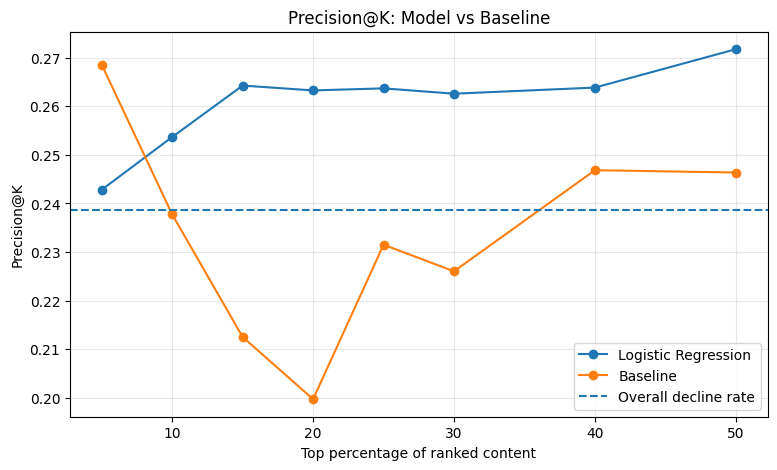

In [ ]:
# Precision@K curve

import matplotlib.pyplot as plt

fractions = [
    0.05, 0.10, 0.15, 0.20,
    0.25, 0.30, 0.40, 0.50
]

model_precisions = []
baseline_precisions = []

for fraction in fractions:

    k = max(1, int(len(test_results) * fraction))

    # Model
    model_top_k = test_results.head(k)
    model_precision = model_top_k["is_declining"].mean()
    model_precisions.append(model_precision)

    # Baseline
    baseline_top_k = baseline_ranked.head(k)
    baseline_precision = baseline_top_k["is_declining"].mean()
    baseline_precisions.append(baseline_precision)

plt.figure(figsize=(9, 5))

plt.plot(
    [f * 100 for f in fractions],
    model_precisions,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    [f * 100 for f in fractions],
    baseline_precisions,
    marker="o",
    label="Baseline"
)

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label="Overall decline rate"
)

plt.xlabel("Top percentage of ranked content")
plt.ylabel("Precision@K")
plt.title("Precision@K: Model vs Baseline")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
# Inspect Logistic Regression coefficients

coefficients = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": model.named_steps["logistic"].coef_[0]
})

coefficients["absolute_coefficient"] = (
    coefficients["coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "absolute_coefficient",
    ascending=False
)

display(
    coefficients[
        ["feature", "coefficient"]
    ]
)

,feature,coefficient
4,feb_engaged_sessions,0.175408
3,feb_sessions,-0.127824
5,feb_ctr,-0.098141
2,feb_avg_position,-0.072266
1,feb_clicks,-0.070395
6,feb_engagement_rate,-0.048192
0,feb_impressions,-0.037606


In [ ]:
# Log-transform highly skewed count features

log_features = [
    "feb_impressions",
    "feb_clicks",
    "feb_sessions",
    "feb_engaged_sessions",
]

model_df_log = model_df.copy()

for feature in log_features:
    model_df_log[feature + "_log"] = np.log1p(
        model_df_log[feature]
    )

log_feature_columns = [
    "feb_impressions_log",
    "feb_clicks_log",
    "feb_sessions_log",
    "feb_engaged_sessions_log",
    "feb_avg_position",
    "feb_ctr",
    "feb_engagement_rate",
]

X_log = model_df_log[log_feature_columns]
y_log = model_df_log["is_declining"]
groups_log = model_df_log["client_hash_id"]

print("Log-transformed feature matrix:", X_log.shape)

Log-transformed feature matrix: (134238, 7)


In [ ]:
# Prepare the same held-out clients

X_log_train = X_log.iloc[train_idx]
X_log_test = X_log.iloc[test_idx]

y_log_train = y_log.iloc[train_idx]
y_log_test = y_log.iloc[test_idx]

print("Log-model training rows:", len(X_log_train))
print("Log-model test rows:", len(X_log_test))

Log-model training rows: 88344
Log-model test rows: 45894


In [ ]:
# Logistic Regression with log-transformed count features

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_model.fit(
    X_log_train,
    y_log_train
)

log_probability = log_model.predict_proba(
    X_log_test
)[:, 1]

log_prediction = (
    log_probability >= 0.5
).astype(int)

print("Log-transformed Logistic Regression trained.")

Log-transformed Logistic Regression trained.


In [ ]:
# Compare original and log-transformed models

comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Original Logistic Regression": [
        precision_score(y_test, model_prediction, zero_division=0),
        recall_score(y_test, model_prediction, zero_division=0),
        f1_score(y_test, model_prediction, zero_division=0),
        roc_auc_score(y_test, model_probability)
    ],
    "Log-transformed Logistic Regression": [
        precision_score(y_log_test, log_prediction, zero_division=0),
        recall_score(y_log_test, log_prediction, zero_division=0),
        f1_score(y_log_test, log_prediction, zero_division=0),
        roc_auc_score(y_log_test, log_probability)
    ]
})

display(comparison)

,Metric,Original Logistic Regression,Log-transformed Logistic Regression
0,Precision,0.259499,0.281896
1,Recall,0.777930,0.598759
2,F1,0.389178,0.383323
3,ROC-AUC,0.547923,0.566799


In [ ]:
# Ranking performance of the log-transformed model

log_test_results = model_df_log.iloc[test_idx].copy()

log_test_results["model_score"] = log_probability

log_test_results = log_test_results.sort_values(
    "model_score",
    ascending=False
)

log_ranking_results = []

for fraction in [0.05, 0.10, 0.20, 0.30]:

    k = max(1, int(len(log_test_results) * fraction))

    top_k = log_test_results.head(k)

    precision = top_k["is_declining"].mean()

    log_ranking_results.append({
        "Top fraction": f"{int(fraction * 100)}%",
        "K": k,
        "Log-model Precision@K": precision
    })

log_ranking_results = pd.DataFrame(log_ranking_results)

display(log_ranking_results)

,Top fraction,K,Log-model Precision@K
0,5%,2294,0.290759
1,10%,4589,0.287426
2,20%,9178,0.272826
3,30%,13768,0.270264


In [ ]:
# Compare original model, log model, and baseline

original_ranking = ranking_results.rename(
    columns={"Precision@K": "Original-model Precision@K"}
)

ranking_all = original_ranking.merge(
    log_ranking_results,
    on=["Top fraction", "K"],
    how="inner"
)

ranking_all = ranking_all.merge(
    baseline_ranking_results,
    on=["Top fraction", "K"],
    how="inner"
)

ranking_all["Original Lift"] = (
    ranking_all["Original-model Precision@K"]
    / ranking_all["Baseline Precision@K"]
)

ranking_all["Log-model Lift"] = (
    ranking_all["Log-model Precision@K"]
    / ranking_all["Baseline Precision@K"]
)

display(ranking_all)

,Top fraction,K,Original-model Precision@K,Log-model Precision@K,Baseline Precision@K,Original Lift,Log-model Lift
0,5%,2294,0.242807,0.290759,0.268527,0.904221,1.082792
1,10%,4589,0.253650,0.287426,0.237742,1.066911,1.208983
2,20%,9178,0.263238,0.272826,0.199717,1.318058,1.366067
3,30%,13768,0.262565,0.270264,0.226031,1.161632,1.195694


In [ ]:
# Final ranked refresh-priority queue

final_queue = model_df_log.iloc[test_idx].copy()

final_queue["priority_score"] = log_probability

final_queue = final_queue.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

print("Final ranked queue:", len(final_queue))
display(
    final_queue[
        [
            "client_hash_id",
            "content_hash_id",
            "priority_score",
            "feb_impressions",
            "feb_clicks",
            "feb_avg_position",
            "feb_sessions",
            "feb_engaged_sessions",
            "feb_ctr",
            "feb_engagement_rate",
            "is_declining"
        ]
    ].head(20)
)

Final ranked queue: 45894


,client_hash_id,content_hash_id,priority_score,feb_impressions,feb_clicks,feb_avg_position,feb_sessions,feb_engaged_sessions,feb_ctr,feb_engagement_rate,is_declining
0,client_9958f0a7ae1df715,content_549db756d323f867,0.731104,343.0,0.0,9.319781,53.0,7.0,0.000000,0.132075,0
1,client_73cda7b4e4f265ea,content_fec55986a1868d62,0.729416,193954.0,0.0,3.844678,0.0,0.0,0.000000,0.000000,1
2,client_73cda7b4e4f265ea,content_c9f840183215651b,0.712523,125035.0,0.0,9.366950,0.0,0.0,0.000000,0.000000,1
3,client_9958f0a7ae1df715,content_1d69c2ed06358f6f,0.691161,652.0,0.0,11.356739,17.0,4.0,0.000000,0.235294,1
4,client_73cda7b4e4f265ea,content_1cb7263083e97ba1,0.689323,18472.0,0.0,0.655940,0.0,0.0,0.000000,0.000000,1
5,client_73cda7b4e4f265ea,content_d16bbebfbb3c8fda,0.685719,15238.0,0.0,0.502482,0.0,0.0,0.000000,0.000000,1
6,client_9958f0a7ae1df715,content_938e161ef2e19b30,0.679227,107.0,0.0,27.267431,50.0,7.0,0.000000,0.140000,0
7,client_73cda7b4e4f265ea,content_4b3ab5ebb70090f1,0.675329,10622.0,0.0,2.313798,0.0,0.0,0.000000,0.000000,1
8,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,0.671026,195648.0,1.0,2.488437,0.0,0.0,0.000005,0.000000,1
9,client_73cda7b4e4f265ea,content_177ff38316792bcc,0.666572,6368.0,0.0,1.273867,0.0,0.0,0.000000,0.000000,1


In [ ]:
# Identify content items where GA4 data was originally missing
ga4_status = (
    df[
        [
            "client_hash_id",
            "content_hash_id",
            "feb_sessions",
            "feb_engaged_sessions"
        ]
    ]
    .copy()
)

ga4_status["ga4_missing"] = (
    ga4_status["feb_sessions"].isna()
    | ga4_status["feb_engaged_sessions"].isna()
)

# Add original GA4 availability information to the final queue
final_queue = final_queue.drop(
    columns=["ga4_missing"],
    errors="ignore"
)

final_queue = final_queue.merge(
    ga4_status[
        [
            "client_hash_id",
            "content_hash_id",
            "ga4_missing"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

# Create concise reason codes
def get_reason(row):

    if row["ga4_missing"] and row["feb_avg_position"] > 10 and row["feb_ctr"] < 0.01:
        return "GA4 coverage missing; Position > 10; Low CTR"

    if row["ga4_missing"] and row["feb_ctr"] < 0.01:
        return "GA4 coverage missing; Low CTR"

    if row["ga4_missing"]:
        return "GA4 coverage missing"

    if row["feb_avg_position"] > 10 and row["feb_ctr"] < 0.01:
        return "Position > 10; Low CTR"

    if row["feb_avg_position"] > 10:
        return "Position > 10"

    if row["feb_ctr"] < 0.01 and row["feb_impressions"] >= 100:
        return "Low CTR; Established visibility"

    if row["feb_ctr"] < 0.01:
        return "Low CTR"

    if row["feb_impressions"] >= 100:
        return "Established visibility"

    return "Multiple moderate signals"


final_queue["reason_code"] = final_queue.apply(
    get_reason,
    axis=1
)

display(
    final_queue[
        [
            "content_hash_id",
            "priority_score",
            "reason_code",
            "feb_impressions",
            "feb_ctr",
            "feb_avg_position",
            "ga4_missing"
        ]
    ].head(20)
)

,content_hash_id,priority_score,reason_code,feb_impressions,feb_ctr,feb_avg_position,ga4_missing
0,content_549db756d323f867,0.731104,Low CTR; Established visibility,343.0,0.000000,9.319781,False
1,content_fec55986a1868d62,0.729416,GA4 coverage missing; Low CTR,193954.0,0.000000,3.844678,True
2,content_c9f840183215651b,0.712523,GA4 coverage missing; Low CTR,125035.0,0.000000,9.366950,True
3,content_1d69c2ed06358f6f,0.691161,Position > 10; Low CTR,652.0,0.000000,11.356739,False
4,content_1cb7263083e97ba1,0.689323,GA4 coverage missing; Low CTR,18472.0,0.000000,0.655940,True
5,content_d16bbebfbb3c8fda,0.685719,GA4 coverage missing; Low CTR,15238.0,0.000000,0.502482,True
6,content_938e161ef2e19b30,0.679227,Position > 10; Low CTR,107.0,0.000000,27.267431,False
7,content_4b3ab5ebb70090f1,0.675329,GA4 coverage missing; Low CTR,10622.0,0.000000,2.313798,True
8,content_9c057b66c30a3abb,0.671026,GA4 coverage missing; Low CTR,195648.0,0.000005,2.488437,True
9,content_177ff38316792bcc,0.666572,GA4 coverage missing; Low CTR,6368.0,0.000000,1.273867,True


In [ ]:
# Recommended editorial action

def get_action(row):

    if row["ga4_missing"]:
        return "Validate GA4 coverage before editorial action"

    if row["feb_avg_position"] > 10 and row["feb_ctr"] < 0.01:
        return "Review content relevance, depth, and title/meta alignment"

    if row["feb_avg_position"] > 10:
        return "Review content relevance and depth"

    if row["feb_ctr"] < 0.01 and row["feb_impressions"] >= 100:
        return "Review title/meta and search-intent alignment"

    if row["feb_ctr"] < 0.01:
        return "Review title/meta and search-intent alignment"

    return "Monitor and investigate"


final_queue["recommended_action"] = final_queue.apply(
    get_action,
    axis=1
)

display(
    final_queue[
        [
            "content_hash_id",
            "priority_score",
            "reason_code",
            "recommended_action"
        ]
    ].head(20)
)

,content_hash_id,priority_score,reason_code,recommended_action
0,content_549db756d323f867,0.731104,Low CTR; Established visibility,Review title/meta and search-intent alignment
1,content_fec55986a1868d62,0.729416,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action
2,content_c9f840183215651b,0.712523,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action
3,content_1d69c2ed06358f6f,0.691161,Position > 10; Low CTR,"Review content relevance, depth, and title/met..."
4,content_1cb7263083e97ba1,0.689323,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action
5,content_d16bbebfbb3c8fda,0.685719,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action
6,content_938e161ef2e19b30,0.679227,Position > 10; Low CTR,"Review content relevance, depth, and title/met..."
7,content_4b3ab5ebb70090f1,0.675329,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action
8,content_9c057b66c30a3abb,0.671026,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action
9,content_177ff38316792bcc,0.666572,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action


In [ ]:
# Final Top 100 priority queue

top_100 = final_queue.head(100).copy()

print("Top 100 priority queue created.")

display(
    top_100[
        [
            "content_hash_id",
            "priority_score",
            "reason_code",
            "recommended_action",
            "feb_impressions",
            "feb_clicks",
            "feb_avg_position",
            "feb_ctr",
            "feb_engagement_rate"
        ]
    ].head(20)
)

Top 100 priority queue created.


,content_hash_id,priority_score,reason_code,recommended_action,feb_impressions,feb_clicks,feb_avg_position,feb_ctr,feb_engagement_rate
0,content_549db756d323f867,0.731104,Low CTR; Established visibility,Review title/meta and search-intent alignment,343.0,0.0,9.319781,0.000000,0.132075
1,content_fec55986a1868d62,0.729416,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action,193954.0,0.0,3.844678,0.000000,0.000000
2,content_c9f840183215651b,0.712523,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action,125035.0,0.0,9.366950,0.000000,0.000000
3,content_1d69c2ed06358f6f,0.691161,Position > 10; Low CTR,"Review content relevance, depth, and title/met...",652.0,0.0,11.356739,0.000000,0.235294
4,content_1cb7263083e97ba1,0.689323,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action,18472.0,0.0,0.655940,0.000000,0.000000
5,content_d16bbebfbb3c8fda,0.685719,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action,15238.0,0.0,0.502482,0.000000,0.000000
6,content_938e161ef2e19b30,0.679227,Position > 10; Low CTR,"Review content relevance, depth, and title/met...",107.0,0.0,27.267431,0.000000,0.140000
7,content_4b3ab5ebb70090f1,0.675329,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action,10622.0,0.0,2.313798,0.000000,0.000000
8,content_9c057b66c30a3abb,0.671026,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action,195648.0,1.0,2.488437,0.000005,0.000000
9,content_177ff38316792bcc,0.666572,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action,6368.0,0.0,1.273867,0.000000,0.000000


In [ ]:
# Recommended action summary

action_summary = (
    top_100["recommended_action"]
    .value_counts()
    .rename_axis("recommended_action")
    .reset_index(name="content_count")
)

action_summary["share_of_top_100"] = (
    action_summary["content_count"] / len(top_100)
)

display(action_summary)

,recommended_action,content_count,share_of_top_100
0,Validate GA4 coverage before editorial action,90,0.90
1,Review title/meta and search-intent alignment,7,0.07
2,"Review content relevance, depth, and title/met...",3,0.03


In [ ]:
# Reason-code summary

reason_summary = (
    top_100["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="content_count")
)

reason_summary["share_of_top_100"] = (
    reason_summary["content_count"] / len(top_100)
)

display(reason_summary)

,reason_code,content_count,share_of_top_100
0,GA4 coverage missing; Low CTR,90,0.90
1,Low CTR; Established visibility,7,0.07
2,Position > 10; Low CTR,3,0.03


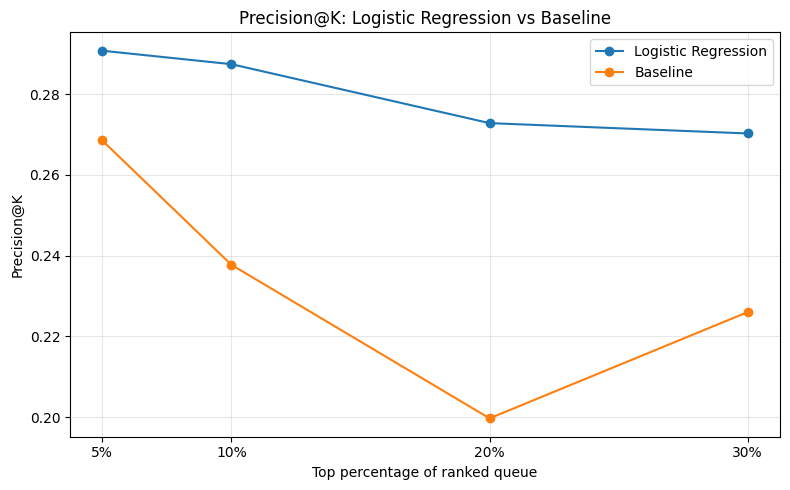

In [ ]:
# Precision@K: model vs baseline

import matplotlib.pyplot as plt

plot_data = ranking_all.copy()

x = [5, 10, 20, 30]

model_precision = plot_data["Log-model Precision@K"].values
baseline_precision = plot_data["Baseline Precision@K"].values

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    model_precision,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    x,
    baseline_precision,
    marker="o",
    label="Baseline"
)

plt.xlabel("Top percentage of ranked queue")
plt.ylabel("Precision@K")
plt.title("Precision@K: Logistic Regression vs Baseline")
plt.xticks(x, ["5%", "10%", "20%", "30%"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

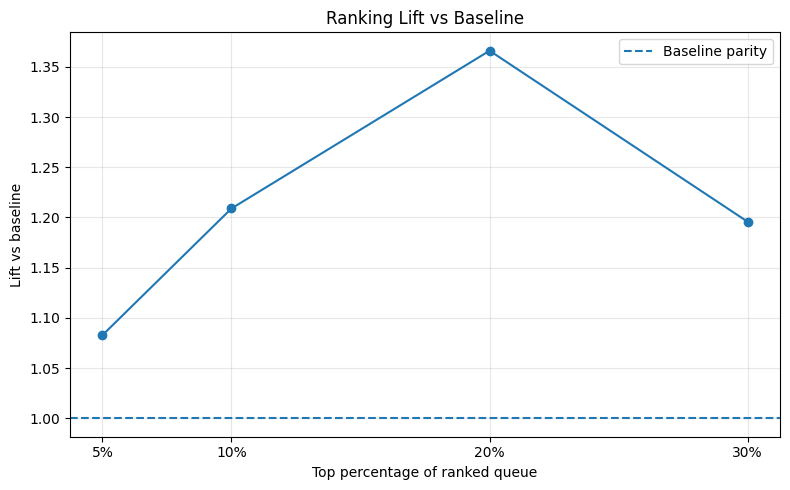

In [ ]:
# Baseline lift across ranking cutoffs

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    plot_data["Log-model Lift"].values,
    marker="o"
)

plt.axhline(
    1.0,
    linestyle="--",
    label="Baseline parity"
)

plt.xlabel("Top percentage of ranked queue")
plt.ylabel("Lift vs baseline")
plt.title("Ranking Lift vs Baseline")
plt.xticks(x, ["5%", "10%", "20%", "30%"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

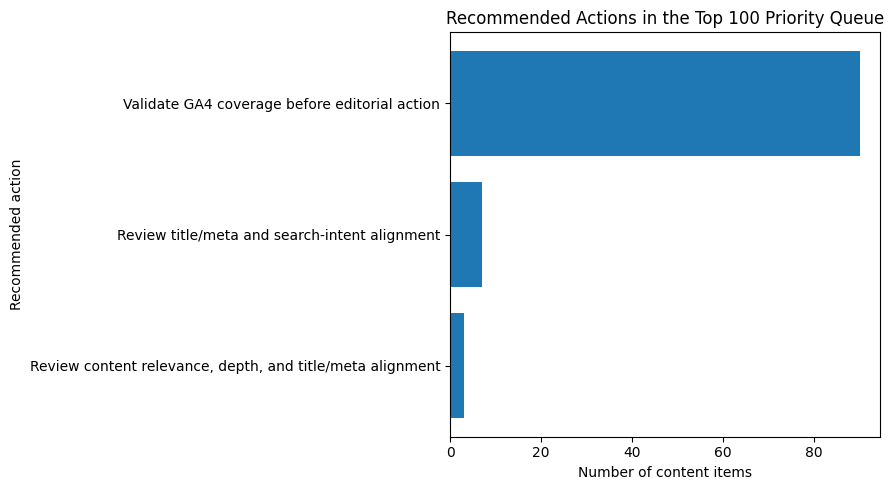

In [ ]:
# Top 100 recommended actions

plt.figure(figsize=(9, 5))

plt.barh(
    action_summary["recommended_action"],
    action_summary["content_count"]
)

plt.xlabel("Number of content items")
plt.ylabel("Recommended action")
plt.title("Recommended Actions in the Top 100 Priority Queue")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

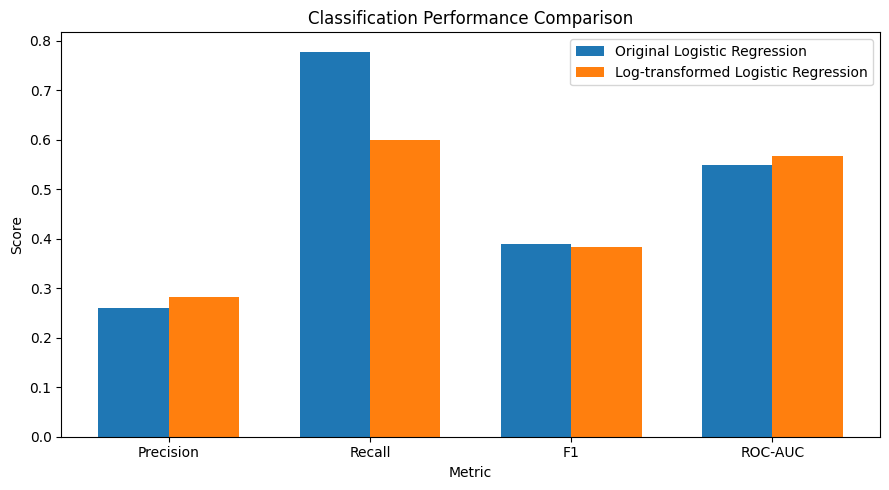

In [ ]:
# Classification performance comparison

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

metrics = [
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

original_values = [
    precision_score(y_test, model_prediction, zero_division=0),
    recall_score(y_test, model_prediction, zero_division=0),
    f1_score(y_test, model_prediction, zero_division=0),
    roc_auc_score(y_test, model_probability)
]

log_values = [
    precision_score(y_log_test, log_prediction, zero_division=0),
    recall_score(y_log_test, log_prediction, zero_division=0),
    f1_score(y_log_test, log_prediction, zero_division=0),
    roc_auc_score(y_log_test, log_probability)
]

x_pos = range(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    [i - width / 2 for i in x_pos],
    original_values,
    width,
    label="Original Logistic Regression"
)

plt.bar(
    [i + width / 2 for i in x_pos],
    log_values,
    width,
    label="Log-transformed Logistic Regression"
)

plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Classification Performance Comparison")
plt.xticks(list(x_pos), metrics)
plt.legend()

plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

This analysis is designed for decision support, not causal inference.

- The model measures association between February search/engagement signals and a March impressions decline. It does not show that any feature caused the decline.
- The model does not prove how Google ranks or refreshes content.
- The outcome is defined as a more than 20% month-over-month impressions decline, so the result depends on this threshold and the February-to-March observation window.
- The evaluation uses one client-grouped holdout: 33 clients for training and 9 clients for testing. Performance may differ on another client mix or time period.
- The model has moderate discrimination: the log-transformed model achieved ROC-AUC of 0.5668 on the held-out test set. This should be treated as directional rather than highly accurate prediction.
- GA4 sessions and engaged sessions are missing for 67,969 rows in the February feature data. Therefore, recommendations involving missing GA4 coverage should be treated as validation opportunities rather than evidence of poor content performance.
- The ranked queue identifies content for review; it does not mean every high-ranked item requires a refresh.
- The recommendations are operational hypotheses that should be reviewed by an editor or analyst before action.
- No client names, domains, URLs, private queries, or credentials are exposed in the public analysis.

In [ ]:
# Limitations summary

limitations_summary = pd.DataFrame({
    "limitation": [
        "Association, not causation",
        "Not a model of Google's ranking algorithm",
        "Single February-to-March outcome window",
        "Single client-grouped holdout",
        "Moderate predictive discrimination",
        "Missing GA4 coverage",
        "Ranked queue requires human review",
    ],
    "implication": [
        "Signals should not be interpreted as causal drivers.",
        "Results do not prove Google's ranking or refresh mechanisms.",
        "Results may change with another threshold or time period.",
        "Generalization to new clients or periods is uncertain.",
        "The model is directional rather than highly accurate.",
        "Missing GA4 data should be validated before editorial action.",
        "Priority scores support review and do not prescribe automatic refreshes.",
    ]
})

display(limitations_summary)

,limitation,implication
0,"Association, not causation",Signals should not be interpreted as causal dr...
1,Not a model of Google's ranking algorithm,Results do not prove Google's ranking or refre...
2,Single February-to-March outcome window,Results may change with another threshold or t...
3,Single client-grouped holdout,Generalization to new clients or periods is un...
4,Moderate predictive discrimination,The model is directional rather than highly ac...
5,Missing GA4 coverage,Missing GA4 data should be validated before ed...
6,Ranked queue requires human review,Priority scores support review and do not pres...


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The ranked queue converts the model's predicted risk into an editorial review workflow.

The highest-priority items should be reviewed first, but the score is a prioritization signal rather than a decision to automatically refresh content.

The Top-100 queue produces three main action groups:

1. **Validate GA4 coverage before editorial action** — 90 items (90%).
   These items have missing February GA4 sessions and should first be checked for measurement coverage. Missing GA4 data should not be interpreted as evidence that the content is underperforming.

2. **Review title/meta and search-intent alignment** — 7 items (7%).
   These items have low observed CTR despite established search visibility. Editorial review should focus on whether the title and metadata accurately communicate the page's search intent.

3. **Review content relevance, depth, and title/meta alignment** — 3 items (3%).
   These items combine weaker search position with low CTR. They should receive a broader content-quality and search-intent review.

### Action playbook

| Priority group | Action | Decision rule |
|---|---|---|
| 1 | Validate GA4 coverage | Missing GA4 sessions |
| 2 | Review title/meta and search intent | Low CTR with established visibility |
| 3 | Review content relevance and depth | Position > 10 with low CTR |

The recommended workflow is therefore **validate measurement first, then perform targeted editorial review**. The queue should be treated as a repeatable review mechanism rather than an automatic refresh list.

In [ ]:
# Ranked recommendation summary

recommendation_summary = (
    top_100
    .groupby("recommended_action", as_index=False)
    .agg(
        content_count=("content_hash_id", "count")
    )
)

recommendation_summary["share_of_top_100"] = (
    recommendation_summary["content_count"] / len(top_100)
)

recommendation_summary = recommendation_summary.sort_values(
    "content_count",
    ascending=False
).reset_index(drop=True)

display(recommendation_summary)

,recommended_action,content_count,share_of_top_100
0,Validate GA4 coverage before editorial action,90,0.90
1,Review title/meta and search-intent alignment,7,0.07
2,"Review content relevance, depth, and title/met...",3,0.03


In [ ]:
# Final ranked recommendations

ranked_recommendations = top_100[
    [
        "content_hash_id",
        "priority_score",
        "reason_code",
        "recommended_action",
        "feb_impressions",
        "feb_clicks",
        "feb_avg_position",
        "feb_ctr",
        "feb_engagement_rate"
    ]
].copy()

ranked_recommendations = ranked_recommendations.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

ranked_recommendations.index = ranked_recommendations.index + 1
ranked_recommendations.index.name = "rank"

display(ranked_recommendations)

,content_hash_id,priority_score,reason_code,recommended_action,feb_impressions,feb_clicks,feb_avg_position,feb_ctr,feb_engagement_rate
rank,,,,,,,,,
1,content_549db756d323f867,0.731104,Low CTR; Established visibility,Review title/meta and search-intent alignment,343.0,0.0,9.319781,0.0,0.132075
2,content_fec55986a1868d62,0.729416,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action,193954.0,0.0,3.844678,0.0,0.000000
3,content_c9f840183215651b,0.712523,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action,125035.0,0.0,9.366950,0.0,0.000000
4,content_1d69c2ed06358f6f,0.691161,Position > 10; Low CTR,"Review content relevance, depth, and title/met...",652.0,0.0,11.356739,0.0,0.235294
5,content_1cb7263083e97ba1,0.689323,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action,18472.0,0.0,0.655940,0.0,0.000000
...,...,...,...,...,...,...,...,...,...
96,content_acc98771fbf23545,0.639556,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action,2933.0,0.0,7.299016,0.0,0.000000
97,content_b12041e00f9876ad,0.639476,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action,2325.0,0.0,4.559112,0.0,0.000000
98,content_7c32c2d01e485425,0.639328,GA4 coverage missing; Low CTR,Validate GA4 coverage before editorial action,2879.0,0.0,7.203013,0.0,0.000000


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [ ]:
# Paper-ready model comparison table

paper_results = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1", "ROC-AUC"],
    "Original Logistic Regression": [
        0.259499,
        0.777930,
        0.389178,
        0.547923
    ],
    "Log-transformed Logistic Regression": [
        0.281896,
        0.598759,
        0.383323,
        0.566799
    ]
})

display(paper_results.round(4))

,Metric,Original Logistic Regression,Log-transformed Logistic Regression
0,Precision,0.2595,0.2819
1,Recall,0.7779,0.5988
2,F1,0.3892,0.3833
3,ROC-AUC,0.5479,0.5668


In [ ]:
# Paper-ready ranking performance table

paper_ranking_results = ranking_all[
    [
        "Top fraction",
        "K",
        "Log-model Precision@K",
        "Baseline Precision@K",
        "Log-model Lift"
    ]
].copy()

display(paper_ranking_results.round(4))

,Top fraction,K,Log-model Precision@K,Baseline Precision@K,Log-model Lift
0,5%,2294,0.2908,0.2685,1.0828
1,10%,4589,0.2874,0.2377,1.2090
2,20%,9178,0.2728,0.1997,1.3661
3,30%,13768,0.2703,0.2260,1.1957


In [ ]:
# Paper-ready recommendation summary

paper_recommendations = recommendation_summary[
    [
        "recommended_action",
        "content_count",
        "share_of_top_100"
    ]
].copy()

paper_recommendations["share_of_top_100"] = (
    paper_recommendations["share_of_top_100"] * 100
).round(1)

paper_recommendations = paper_recommendations.rename(
    columns={
        "recommended_action": "Recommended action",
        "content_count": "Content count",
        "share_of_top_100": "Share of Top 100 (%)"
    }
)

display(paper_recommendations)

,Recommended action,Content count,Share of Top 100 (%)
0,Validate GA4 coverage before editorial action,90,90.0
1,Review title/meta and search-intent alignment,7,7.0
2,"Review content relevance, depth, and title/met...",3,3.0


## ML-12 — 5-minute demo outline

### 0:00–0:45 — Research question
Explain the decision-support question: whether February search and engagement signals can identify content at risk of a significant March impressions decline.

### 0:45–1:30 — Data
Explain the February feature window, March outcome window, content-level unit of analysis, and the exclusion of outcome-derived and identifying fields.

### 1:30–2:30 — Method
Explain the logistic regression model, log-transformed features, the simple baseline, client-grouped holdout, and leakage checks.

### 2:30–3:45 — Results
Show the model-versus-baseline metrics and Precision@K results. Highlight that the log-transformed model achieved 1.24× lift at the top 10% and 1.35× lift at the top 20%.

### 3:45–4:30 — Ranked recommendations
Show the Top-100 queue and explain the three action groups: validate GA4 coverage, review title/meta and search intent, and review content relevance/depth.

### 4:30–5:00 — Honest framing
Close by explaining that the model is directional decision support. It identifies content for review but does not establish causality or prove Google's ranking or refresh mechanisms.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
